In [113]:
import os
import librosa
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [114]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=2.5, offset=0.6)
    # Data augmentation
    if np.random.rand() < 0.5:
        y = librosa.effects.pitch_shift(y, sr=sr, n_steps=np.random.uniform(-2, 2))  # <-- FIXED LINE
    if np.random.rand() < 0.5:
        y = librosa.effects.time_stretch(y, rate=np.random.uniform(0.8, 1.2))
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    mel_spec_db_mean = np.mean(mel_spec_db.T, axis=0)
    return mel_spec_db_mean

In [115]:
root_directory = r"C:\Users\User\OneDrive\Desktop\major project\acoustic_audio"


In [116]:
features, labels = [], []
for label in os.listdir(root_directory):
    folder_path = os.path.join(root_directory, label)
    if not os.path.isdir(folder_path):
        continue
    for file in os.listdir(folder_path)[:100]:
        try:
            file_path = os.path.join(folder_path, file)
            feat = extract_features(file_path)
            features.append(feat)
            labels.append(label)
        except Exception as e:
            print(f"Error with {file}: {e}")

C:\Users\User\AppData\Local\Temp\ipykernel_9744\1648885917.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, duration=2.5, offset=0.6)
c:\Users\User\OneDrive\Desktop\major project\.venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
c:\Users\User\OneDrive\Desktop\major project\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=0
  warnings.warn(
c:\Users\User\OneDrive\Desktop\major project\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=315
  warnings.warn(
c:\Users\User\OneDrive\Desktop\major project\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal

In [117]:
X = np.array(features)
y = np.array(labels)

In [118]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [119]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [120]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [121]:
class AudioDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(2)  # shape: (N, features, 1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [122]:
train_dataset = AudioDataset(X_train, y_train)
test_dataset = AudioDataset(X_test, y_test)

In [123]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [124]:
class AudioCNN(nn.Module):
    def __init__(self, num_classes, input_shape):
        super(AudioCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 64, kernel_size=3)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(2)

        with torch.no_grad():
            x = torch.zeros(1, 1, input_shape)
            x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
            x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
            n_features = x.shape[1] * x.shape[2]

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(n_features, 128)
        self.dropout = nn.Dropout(0.5)  # Increased dropout
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [125]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AudioCNN(num_classes=len(np.unique(y)), input_shape=X_train.shape[1]).to(device)


In [126]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [127]:
epochs = 100
train_acc, val_acc = [], []

In [128]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)

for epoch in range(epochs):
    model.train()
    correct, total = 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
    train_accuracy = 100 * correct / total

    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    val_accuracy = 100 * correct / total

    train_acc.append(train_accuracy)
    val_acc.append(val_accuracy)
    
    scheduler.step(val_accuracy)

    print(f"Epoch {epoch+1}/{epochs}, Train Acc: {train_accuracy:.2f}%, Val Acc: {val_accuracy:.2f}%")


Epoch 1/100, Train Acc: 15.16%, Val Acc: 33.83%
Epoch 2/100, Train Acc: 29.72%, Val Acc: 40.06%
Epoch 3/100, Train Acc: 36.26%, Val Acc: 50.74%
Epoch 4/100, Train Acc: 42.12%, Val Acc: 54.30%
Epoch 5/100, Train Acc: 44.58%, Val Acc: 59.94%
Epoch 6/100, Train Acc: 49.70%, Val Acc: 58.75%
Epoch 7/100, Train Acc: 52.53%, Val Acc: 61.13%
Epoch 8/100, Train Acc: 53.94%, Val Acc: 60.53%
Epoch 9/100, Train Acc: 56.46%, Val Acc: 57.27%
Epoch 10/100, Train Acc: 54.61%, Val Acc: 64.39%
Epoch 11/100, Train Acc: 59.06%, Val Acc: 62.61%
Epoch 12/100, Train Acc: 60.18%, Val Acc: 67.66%
Epoch 13/100, Train Acc: 61.81%, Val Acc: 64.69%
Epoch 14/100, Train Acc: 63.30%, Val Acc: 66.17%
Epoch 15/100, Train Acc: 61.66%, Val Acc: 63.80%
Epoch 16/100, Train Acc: 65.45%, Val Acc: 63.80%
Epoch 17/100, Train Acc: 60.10%, Val Acc: 67.06%
Epoch 18/100, Train Acc: 64.56%, Val Acc: 66.47%
Epoch 19/100, Train Acc: 66.20%, Val Acc: 65.28%
Epoch 20/100, Train Acc: 70.73%, Val Acc: 67.36%
Epoch 21/100, Train Acc: 68.2

In [129]:
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())

In [130]:
print(f"Final Train Accuracy: {train_acc[-1]:.2f}%")
print(f"Final Validation Accuracy: {val_acc[-1]:.2f}%")

Final Train Accuracy: 81.13%
Final Validation Accuracy: 69.44%


<Figure size 1000x800 with 0 Axes>

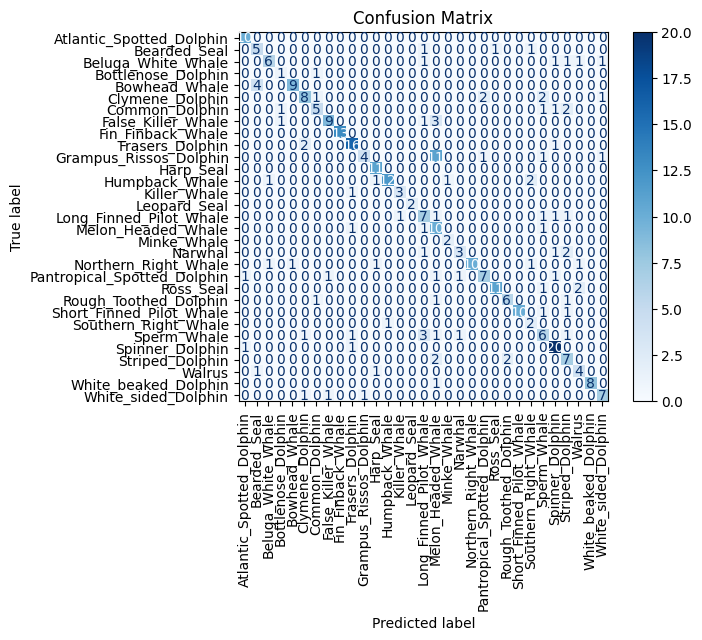

In [131]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# make sure you already have all_labels and all_preds
cm = confusion_matrix(all_labels, all_preds)

# only use the labels that actually appeared in your test set
used_labels = np.unique(all_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_[used_labels]  # match labels to cm
)
plt.figure(figsize=(10, 8))
disp.plot(cmap="Blues", xticks_rotation=90)
plt.title("Confusion Matrix")
plt.show()


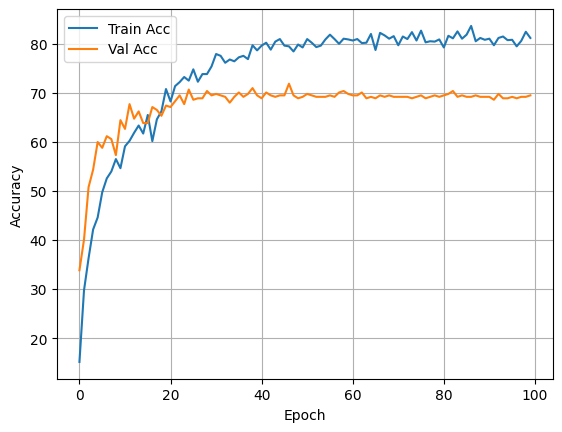

In [132]:
plt.plot(train_acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()